# Tamimi Supermarket Data Analysis in Saudi Arabia

## Project Overview

This project analyzes product pricing data from Tamimi supermarket in Saudi Arabia.  
The goal is to understand pricing patterns, product variety, company distribution, price categories, and product size trends.

The analysis includes data cleaning, exploratory data analysis, visualizations, and key insights that can support business understanding and dashboard development.

## Data Description

The dataset contains product information from Tamimi supermarket in Saudi Arabia.  
It includes 1,220 product records and 6 original columns.

The main columns are:

- Company: The company or brand name.
- Product: The product name.
- Size: The product package size.
- Currency: The currency used for pricing.
- Prices: The product price in Saudi Riyal.
- Price_Category: A new column created to classify products into price groups.

In [5]:
import pandas as pd

df = pd.read_csv("tamimimarkets.csv")
df.head()

,Unnamed: 0,Company,Product,Size,Currency,Prices
0,0,Goody,Whole Kernel Golden Corn,340G,SAR,3.25
1,1,Goody,Original Mayonnaise,332 Ml,SAR,7.75
2,2,Goody,Ranch Dressing,237 Ml,SAR,7.95
3,3,Halwani Brothers,AlNakhla Finest Halawa Plain,250G,SAR,9.40
4,4,7 UP,Can,150 Ml,SAR,1.50


In [6]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1220 non-null   int64  
 1   Company     1220 non-null   object 
 2   Product     1220 non-null   object 
 3   Size        1220 non-null   object 
 4   Currency    1220 non-null   object 
 5   Prices      1220 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 57.3+ KB


Unnamed: 0    0
Company       0
Product       0
Size          0
Currency      0
Prices        0
dtype: int64

In [7]:
df = df.drop(columns=["Unnamed: 0"])
df.head()

,Company,Product,Size,Currency,Prices
0,Goody,Whole Kernel Golden Corn,340G,SAR,3.25
1,Goody,Original Mayonnaise,332 Ml,SAR,7.75
2,Goody,Ranch Dressing,237 Ml,SAR,7.95
3,Halwani Brothers,AlNakhla Finest Halawa Plain,250G,SAR,9.40
4,7 UP,Can,150 Ml,SAR,1.50


In [9]:
print("Companies:")
print(df["Company"].unique())

print("\nCurrencies:")
print(df["Currency"].unique())

print("\nNumber of unique products:")
print(df["Product"].nunique())

print("\nFirst 10 products:")
print(df["Product"].head(10))

Companies:
['Goody ' 'Halwani Brothers ' '7 UP ' 'Afia ' 'Al Alali ' 'Galaxy '
 'Al Arabi ' 'Godiva ' "Kellogg's " 'Kikkoman ' 'Kinder ' 'Kettle '
 'Lays ' 'Lindt ' "Libby's " 'Klast ' 'KitKat ' 'Kuwait Bakeries '
 'Langnese ' 'Kohinoor ' 'Heinz ' 'Holsten ' "Hershey's " 'Nescafe '
 'Nestlé ' 'Loacker ' 'Lipton ' 'M&M ' 'Maggi ' 'Mars ' 'Maltesers '
 'Mirinda ' 'Mazola ' 'Minis ' 'Mountain Dew ' "Mcvitie's " 'Moussy '
 'Nadec ' 'Punjabi Al Muhaidib ' 'Perrier ' 'Rainbow ' 'Premium Harvest '
 'Rauch ' 'Rio Mare ' 'Rahma ' 'Nova ' 'Nutella ' 'Noor '
 'Orient Gardens ' 'Pepsi ' 'Yamama ' 'Ruffles ' 'Snickers ' 'Saudia '
 'Sriracha ' 'Twinings ' 'Tabasco ' 'Tasali ' 'Ulker ' 'Twix '
 'Coca Cola ' 'Evian ' 'Al Safi ' 'Volvic ' 'Sipa ' 'Barbican ' 'Best '
 'Indomie ' 'Caesar ' 'KDD ' 'Al Rabie ' 'Ferrero Rocher ' 'Toblerone '
 "Green's " "Florida's Natural " 'Vimto ' 'Bugles ' 'Bahlsen '
 'Canada Dry ' 'Nada ' 'Atlas ' 'Puck ' 'Fanta ' "Foster Clark's "
 'Shani ' 'Suntop ' 'Riyadh Food ' 'Pr

ترتيب اسماء الشركات والمنتجات


In [10]:
df.columns = df.columns.str.strip()

df["Company"] = df["Company"].str.strip()
df["Product"] = df["Product"].str.strip()
df["Size"] = df["Size"].str.strip()
df["Currency"] = df["Currency"].str.strip()

df.head()

,Company,Product,Size,Currency,Prices
0,Goody,Whole Kernel Golden Corn,340G,SAR,3.25
1,Goody,Original Mayonnaise,332 Ml,SAR,7.75
2,Goody,Ranch Dressing,237 Ml,SAR,7.95
3,Halwani Brothers,AlNakhla Finest Halawa Plain,250G,SAR,9.40
4,7 UP,Can,150 Ml,SAR,1.50


التأكد من نوع عمود السعر

In [11]:
df["Prices"].dtype
df["Prices"].describe()

count    1220.000000
mean       12.302049
std        11.851204
min         0.300000
25%         4.500000
50%         9.500000
75%        16.950000
max       123.000000
Name: Prices, dtype: float64

إنشاء أول مؤشرات تحليلية KPIs

In [12]:
total_companies = df["Company"].nunique()
total_products = df["Product"].nunique()
average_price = df["Prices"].mean()
max_price = df["Prices"].max()
min_price = df["Prices"].min()

print("Number of companies:", total_companies)
print("Number of unique products:", total_products)
print("Average price:", round(average_price, 2), "SAR")
print("Highest price:", max_price, "SAR")
print("Lowest price:", min_price, "SAR")

Number of companies: 304
Number of unique products: 1080
Average price: 12.3 SAR
Highest price: 123.0 SAR
Lowest price: 0.3 SAR


تحليل أغلى 10 منتجات

In [13]:
top_expensive_products = df.sort_values(by="Prices", ascending=False).head(10)

top_expensive_products

,Company,Product,Size,Currency,Prices
894,Volvic,Mineral Water,24x330 Ml,SAR,123.00
912,GOLDEN,Frozen Chicken,900 GM,SAR,111.95
135,Evian,Natural Mineral Water,24 x 500 Ml,SAR,100.95
1051,DANYA,White Grape Juice,12 x 1L,SAR,86.25
864,Punjabi Al Muhaidib,White Basmati Rice,10Kg,SAR,74.50
51,Kohinoor,Indian Basmati Rice,5Kg,SAR,68.50
957,AL AILA,White Basmati Rice,10Kg,SAR,64.95
462,Rainbow,Full Cream Milk Powder,1.8kg,SAR,64.95
920,AL WALIMA,Sella Basmati Rice,10Kg,SAR,64.95
918,INDIA GATE,Classic White Basmati Rice Ambar,5Kg,SAR,63.95


تحليل أرخص 10 منتجات.

In [14]:
cheapest_products = df.sort_values(by="Prices", ascending=True).head(10)

cheapest_products

,Company,Product,Size,Currency,Prices
1179,Tamimi Markets,Bottled drinking water,200ML,SAR,0.30
330,Naqi,Water Bottle,200 Ml,SAR,0.40
931,Berain,Drinking Water,200 Ml,SAR,0.50
113,Nestlé,Pure Life Water,330 Ml,SAR,0.50
1036,Aquafina,Dinking Water,200 Ml,SAR,0.50
290,Fonte,Vanilla CupCake,30G,SAR,0.55
153,Nova,Chewing Gum Spearmint Sugar Free,2.5G,SAR,0.55
386,Nova,Chewing Gum Peppermint Sugar Free,5 x 2.5G,SAR,0.55
228,Nova,Chewing Gum Fruit Sugar Free,5 x 2.5G,SAR,0.55
141,Best,Salted Peanuts,4 x 330 Ml,SAR,0.60


أكثر الشركات التي لديها منتجات في الداتا

In [15]:
top_companies = df["Company"].value_counts().head(10)

top_companies

Company
Tamimi Markets    52
Goody             47
Freshly           40
Nestlé            31
Almarai           30
Betty Crocker     25
Galaxy            22
Americana         20
Al Safi           19
Lusine            19
Name: count, dtype: int64

تحليل متوسط السعر لكل شركة.

In [16]:
avg_price_by_company = df.groupby("Company")["Prices"].mean().sort_values(ascending=False).head(10)

avg_price_by_company

Company
GOLDEN          111.95
DANYA            86.25
Kohinoor         68.50
AL WALIMA        64.95
Volvic           64.75
Melitta          54.95
Night Orient     52.50
AL AILA          52.45
Abu Khrof        51.50
Siblou           50.95
Name: Prices, dtype: float64

متوسط السعر لأعلى 10 شركات.

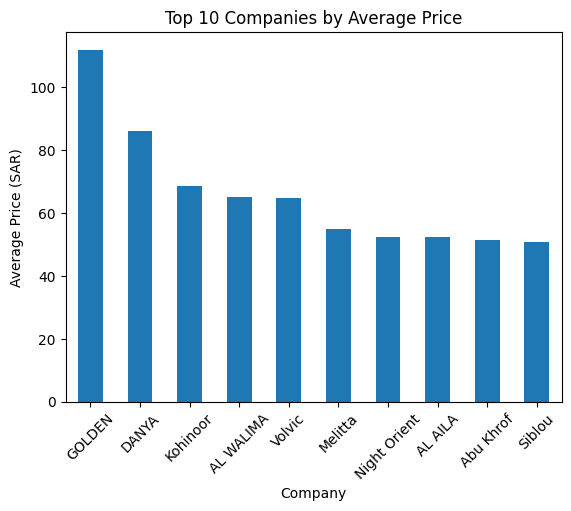

In [17]:
import matplotlib.pyplot as plt

avg_price_by_company.plot(kind="bar")

plt.title("Top 10 Companies by Average Price")
plt.xlabel("Company")
plt.ylabel("Average Price (SAR)")
plt.xticks(rotation=45)
plt.show()

أكثر 10 شركات من ناحية عدد المنتجات

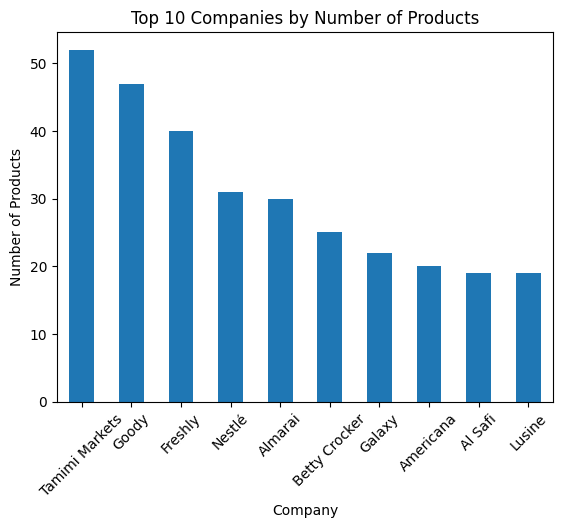

In [18]:
top_companies.plot(kind="bar")

plt.title("Top 10 Companies by Number of Products")
plt.xlabel("Company")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

تحليل توزيع الأسعار

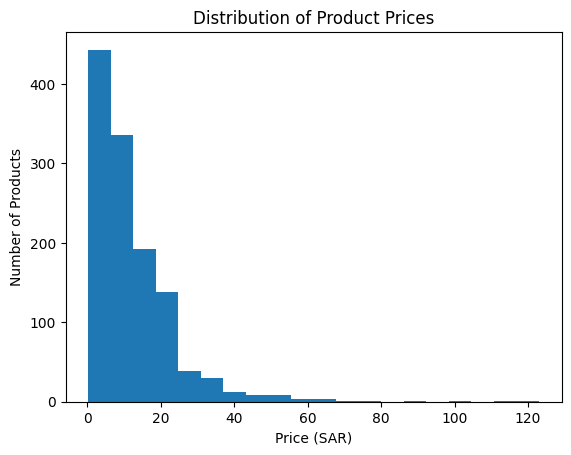

In [19]:
plt.hist(df["Prices"], bins=20)

plt.title("Distribution of Product Prices")
plt.xlabel("Price (SAR)")
plt.ylabel("Number of Products")
plt.show()

تحليل عدد المنتجات حسب فئات السعر.

In [20]:
def price_category(price):
    if price < 5:
        return "Low Price"
    elif price < 20:
        return "Medium Price"
    elif price < 50:
        return "High Price"
    else:
        return "Very High Price"

df["Price_Category"] = df["Prices"].apply(price_category)

df["Price_Category"].value_counts()

Price_Category
Medium Price       671
Low Price          345
High Price         184
Very High Price     20
Name: count, dtype: int64

رسم فئات الأسعار

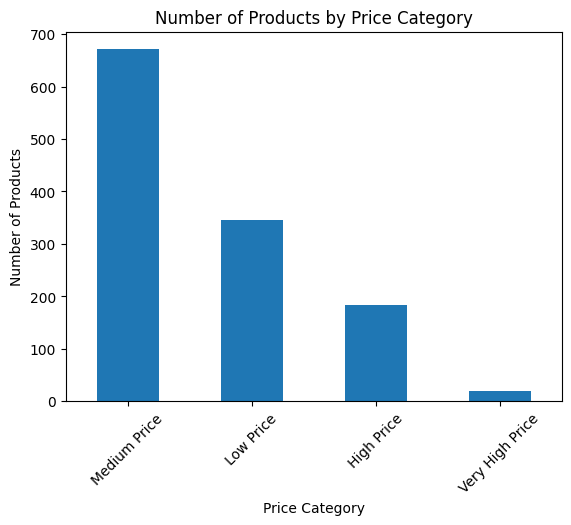

In [21]:
price_category_counts = df["Price_Category"].value_counts()

price_category_counts.plot(kind="bar")

plt.title("Number of Products by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

تحليل متوسط السعر حسب فئة السعر

In [22]:
avg_price_category = df.groupby("Price_Category")["Prices"].mean().sort_values(ascending=False)

avg_price_category

Price_Category
Very High Price    68.862500
High Price         27.716304
Medium Price       11.314829
Low Price           2.722319
Name: Prices, dtype: float64

رسم متوسط السعر حسب فئة السعر.

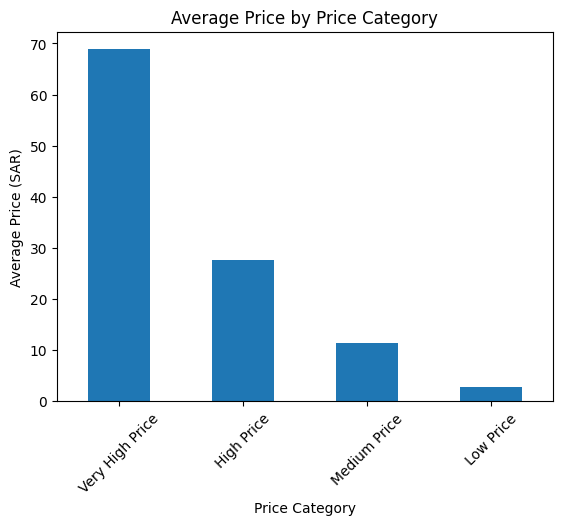

In [23]:
avg_price_category.plot(kind="bar")

plt.title("Average Price by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Average Price (SAR)")
plt.xticks(rotation=45)
plt.show()

معرفة الشركات التي عندها منتجات Very High Price

In [24]:
very_high_products = df[df["Price_Category"] == "Very High Price"]

very_high_products[["Company", "Product", "Size", "Prices"]].sort_values(by="Prices", ascending=False)

,Company,Product,Size,Prices
894,Volvic,Mineral Water,24x330 Ml,123.00
912,GOLDEN,Frozen Chicken,900 GM,111.95
135,Evian,Natural Mineral Water,24 x 500 Ml,100.95
1051,DANYA,White Grape Juice,12 x 1L,86.25
864,Punjabi Al Muhaidib,White Basmati Rice,10Kg,74.50
51,Kohinoor,Indian Basmati Rice,5Kg,68.50
462,Rainbow,Full Cream Milk Powder,1.8kg,64.95
920,AL WALIMA,Sella Basmati Rice,10Kg,64.95
957,AL AILA,White Basmati Rice,10Kg,64.95
918,INDIA GATE,Classic White Basmati Rice Ambar,5Kg,63.95


تحليل الشركات التي لديها أكبر عدد من المنتجات في فئة Very High Price.

In [25]:
very_high_company_counts = very_high_products["Company"].value_counts()

very_high_company_counts

Company
Melitta                2
Al Shalan              2
INDIA GATE             2
Kohinoor               1
GOLDEN                 1
KDD                    1
Abu Khrof              1
AL AILA                1
AL WALIMA              1
Abu kass               1
Evian                  1
Volvic                 1
Punjabi Al Muhaidib    1
Siblou                 1
Night Orient           1
Rainbow                1
DANYA                  1
Name: count, dtype: int64

رسم الشركات التي لديها منتجات Very High Price.

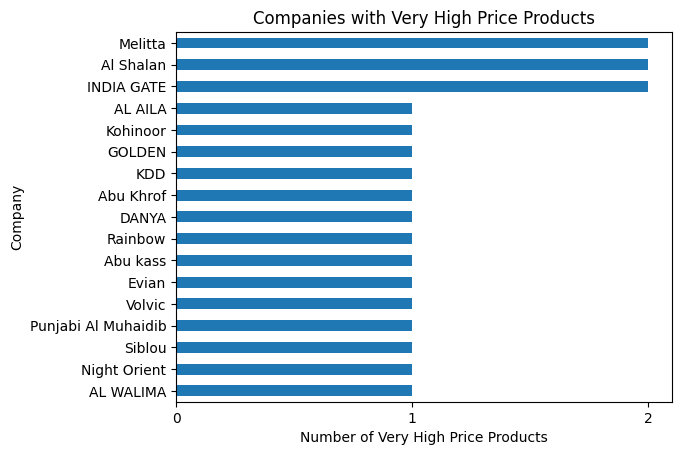

In [27]:
very_high_company_counts = very_high_company_counts.sort_values()

very_high_company_counts.plot(kind="barh")

plt.title("Companies with Very High Price Products")
plt.xlabel("Number of Very High Price Products")
plt.ylabel("Company")
plt.xticks([0, 1, 2])
plt.show()

تحليل المنتجات حسب الحجم اكثر الاحجام المتكررة  Size.

In [28]:
top_sizes = df["Size"].value_counts().head(10)

top_sizes

Size
400G      58
100G      43
500G      41
200G      29
250G      26
450G      22
170G      22
330 Ml    21
200 Ml    20
250 Ml    17
Name: count, dtype: int64

رسم أكثر 10 أحجام تكرارًا.

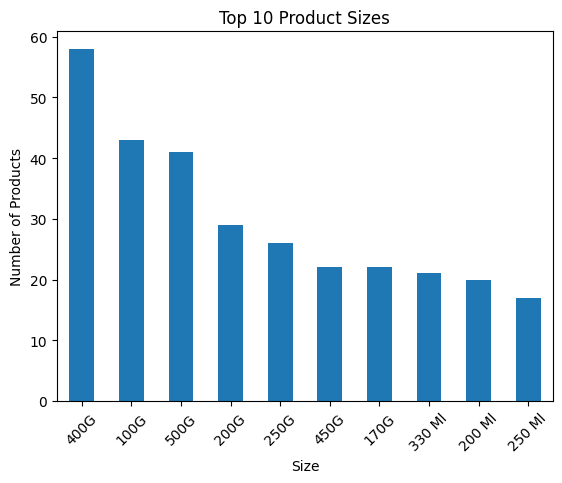

In [29]:
top_sizes.plot(kind="bar")

plt.title("Top 10 Product Sizes")
plt.xlabel("Size")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

تحليل متوسط السعر حسب الحجم Size.

In [30]:
avg_price_by_size = df.groupby("Size")["Prices"].mean().sort_values(ascending=False).head(10)

avg_price_by_size

Size
24x330 Ml      123.0000
900 GM         111.9500
24 x 500 Ml    100.9500
1.8kg           64.9500
40 x 125Ml      59.5000
10Kg            56.8375
1.8Kg           47.9500
225G            47.9500
269G            47.2500
305G            45.9500
Name: Prices, dtype: float64

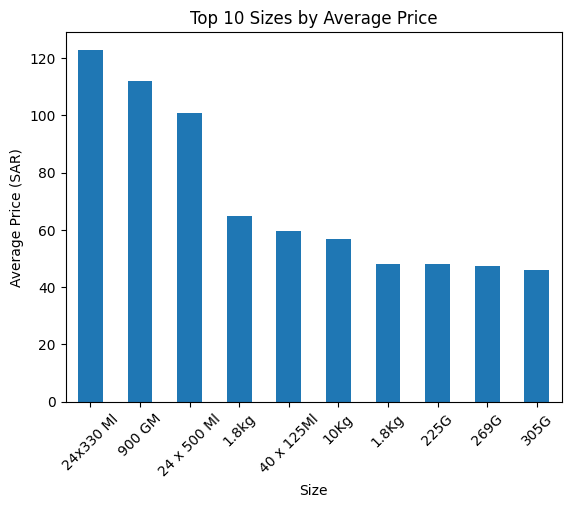

In [31]:
avg_price_by_size.plot(kind="bar")

plt.title("Top 10 Sizes by Average Price")
plt.xlabel("Size")
plt.ylabel("Average Price (SAR)")
plt.xticks(rotation=45)
plt.show()

كل المنتجات بعملة SAR فقط أو توجد عملات أخرى.

In [32]:
df["Currency"].value_counts()

Currency
SAR    1220
Name: count, dtype: int64

In [33]:
df.to_csv("clean_tamimi_data.csv", index=False)

## Key Insights

- The dataset contains 1,220 products from 304 companies.
- There are 1,080 unique products in the dataset.
- All prices are listed in Saudi Riyal (SAR).
- The average product price is approximately 12.30 SAR.
- Most products are priced below 20 SAR.
- The medium-price category contains the largest number of products.
- Very high-priced products represent only a small portion of the dataset.
- Tamimi Markets has the highest number of products, followed by Goody and Freshly.
- GOLDEN has the highest average price among companies.
- The most common product sizes are 400G, 100G, and 500G.
- Larger package sizes and multi-pack items usually have higher average prices.

## Research Questions

This project answers the following questions:

1. What are the general pricing patterns of Tamimi supermarket products?
2. Which companies have the highest number of products?
3. Which products are the most expensive and the least expensive?
4. How are products distributed across different price categories?
5. Which companies have the highest average product prices?
6. What are the most common product sizes?
7. How does product size relate to average price?